In [ ]:
!pip install kaggle --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!rm -rf ~/.kaggle
!mkdir ~/.kaggle
!cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download phhasian0710/seed-iv/
! unzip seed-iv.zip

Dataset URL: https://www.kaggle.com/datasets/phhasian0710/seed-iv/versions/
License(s): unknown
100% 13.7G/13.7G [03:01<00:00, 81.1MB/s]

Archive:  seed-iv.zip
  inflating: Channel Order.xlsx      
  inflating: ReadMe.txt              
  inflating: eeg_feature_smooth/1/10_20151014.mat  
  inflating: eeg_feature_smooth/1/11_20150916.mat  
  inflating: eeg_feature_smooth/1/12_20150725.mat  
  inflating: eeg_feature_smooth/1/13_20151115.mat  
  inflating: eeg_feature_smooth/1/14_20151205.mat  
  inflating: eeg_feature_smooth/1/15_20150508.mat  
  inflating: eeg_feature_smooth/1/1_20160518.mat  
  inflating: eeg_feature_smooth/1/2_20150915.mat  
  inflating: eeg_feature_smooth/1/3_20150919.mat  
  inflating: eeg_feature_smooth/1/4_20151111.mat  
  inflating: eeg_feature_smooth/1/5_20160406.mat  
  inflating: eeg_feature_smooth/1/6_20150507.mat  
  inflating: eeg_feature_smooth/1/7_20150715.mat  
  inflating: eeg_feature_smooth/1/8_20151103.mat  
  inflating: eeg_feature_smooth/1/9_20151028

In [ ]:
import scipy.io as sio
import glob

mat = sio.loadmat("/content/eeg_raw_data/1/14_20151205.mat")

# Get all trial keys
trial_keys = sorted([k for k in mat.keys() if k.endswith(tuple([str(i) for i in range(1, 25)]))])
print(trial_keys)  # check key names

trial1 = mat[trial_keys[0]]
print(trial1.shape)

['zjd_eeg1', 'zjd_eeg10', 'zjd_eeg11', 'zjd_eeg12', 'zjd_eeg13', 'zjd_eeg14', 'zjd_eeg15', 'zjd_eeg16', 'zjd_eeg17', 'zjd_eeg18', 'zjd_eeg19', 'zjd_eeg2', 'zjd_eeg20', 'zjd_eeg21', 'zjd_eeg22', 'zjd_eeg23', 'zjd_eeg24', 'zjd_eeg3', 'zjd_eeg4', 'zjd_eeg5', 'zjd_eeg6', 'zjd_eeg7', 'zjd_eeg8', 'zjd_eeg9']
(62, 33601)


In [ ]:

import numpy as np
import scipy.io
import scipy.signal
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

# --- Constants ---
NUM_SUBJECTS = 15
NUM_SESSIONS = 3
NUM_CHANNELS = 62
NUM_BANDS = 5  # Delta, Theta, Alpha, Beta, Gamma
SAMPLING_RATE = 200 # SEED-IV sampling rate

# 1. Channel Configuration (Standard 10-20 System)
SEED_CHANNELS = [
    'FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ',
    'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2',
    'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4',
    'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6',
    'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8',
    'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ',
    'O2', 'CB2'
]

# 2. Session Label Definition (0: Neutral, 1: Sad, 2: Fear, 3: Happy)
SESSION_LABELS = {
    1: [1, 2, 3, 0, 2, 0, 0, 1, 0, 1, 2, 1, 1, 1, 2, 3, 2, 2, 3, 3, 0, 3, 0, 3],
    2: [2, 1, 3, 0, 0, 2, 0, 2, 3, 3, 2, 3, 2, 0, 1, 1, 2, 1, 0, 3, 0, 1, 3, 1],
    3: [1, 2, 2, 1, 3, 3, 3, 1, 1, 2, 1, 0, 2, 3, 3, 0, 2, 3, 0, 0, 2, 0, 1, 0]
}

In [ ]:
session_id=2
subject_id=14
trial_idx=1
channel_name='FP1'

raw_path = os.path.join("/content/eeg_raw_data", str(session_id))
raw_files = sorted(glob.glob(os.path.join(raw_path, '*.mat')))

subj_file = next((f for f in raw_files if os.path.basename(f).startswith(f"{subject_id}_")), None)

if not subj_file:
    print("Raw file not found for visualization.")


mat_raw = scipy.io.loadmat(subj_file)
all_keys = list(mat_raw.keys())
first_trial_key = next((key for key in all_keys if key.endswith('_eeg1')), None)
prefix = first_trial_key[:-5]
raw_key = f"{prefix}_eeg{trial_idx+1}"

if raw_key not in mat_raw:
    print(f"Key {raw_key} not found.")

raw_data = mat_raw[raw_key]
ch_idx = SEED_CHANNELS.index(channel_name)
raw_signal = raw_data[ch_idx, :1000] # First 5 seconds

# 2. Filter Bands (Butterworth)
bands = {
    'Delta (1-4Hz)': (1, 4), 'Theta (4-8Hz)': (4, 8),
    'Alpha (8-14Hz)': (8, 14), 'Beta (14-31Hz)': (14, 31),
    'Gamma (31-50Hz)': (31, 50)
}



In [ ]:
def compute_differential_entropy(signal):
    """Computes DE for a signal assuming Gaussian distribution: 0.5 * log(2*pi*e*var)"""
    # Small epsilon to avoid log(0)
    variance = np.var(signal, ddof=1) + 1e-8
    return 0.5 * np.log(2 * np.pi * np.e * variance)

def z_score(data):
    """Normalize data for visualization comparison"""
    return (data - np.mean(data)) / (np.std(data) + 1e-8)

In [ ]:
# Get Raw Data (Channels x Time)

filtered_signals = {}
for band, (low, high) in bands.items():
    sos = scipy.signal.butter(4, [low, high], btype='bandpass', fs=200, output='sos')
    filtered_signals[band] = scipy.signal.sosfilt(sos, raw_signal)

# 3. Load Smoothed Feature (LDS) vs Compute Raw DE
# We switch to BETA BAND (Index 3) for better visibility
TARGET_BAND_IDX = 3
TARGET_BAND_NAME = "Beta"
TARGET_FREQ = [14, 31]

# Compute Raw DE manually
n_windows = raw_data.shape[1] // 200
noisy_de_series = []

full_signal = raw_data[ch_idx, :]
band_sos = scipy.signal.butter(4, TARGET_FREQ, btype='bandpass', fs=200, output='sos')
full_band_sig = scipy.signal.sosfilt(band_sos, full_signal)


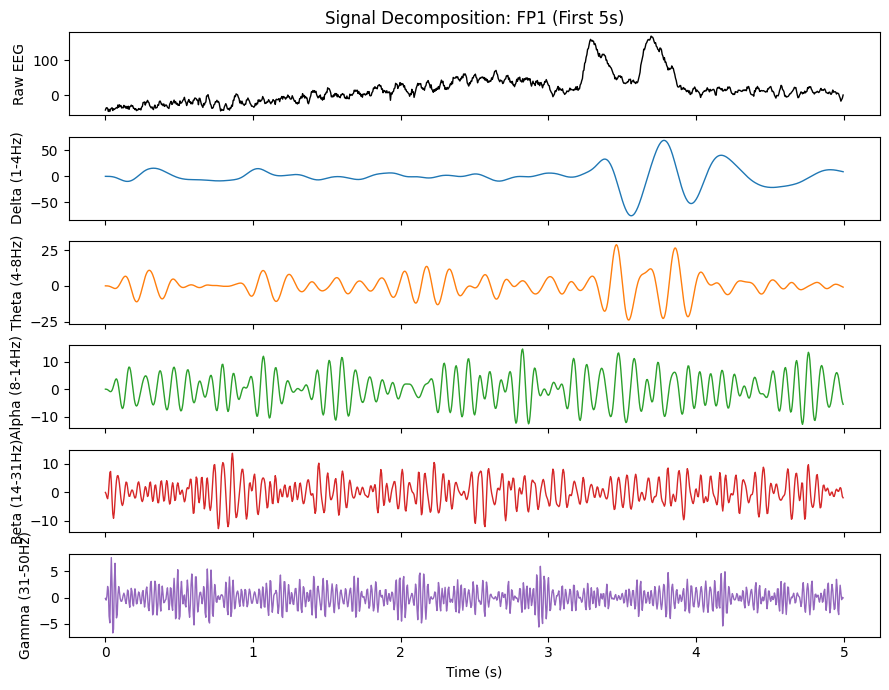

In [ ]:
for w in range(n_windows):
    window = full_band_sig[w*200 : (w+1)*200]
    noisy_de_series.append(compute_differential_entropy(window))

# Load Pre-computed LDS Feature
smooth_path = os.path.join('/content/eeg_feature_smooth', str(session_id), os.path.basename(subj_file))
mat_smooth = scipy.io.loadmat(smooth_path)
smooth_key = f"de_LDS{trial_idx+1}"

# Shape: (62, windows, 5) -> Get Beta Band
smooth_de_series = mat_smooth[smooth_key][ch_idx, :, TARGET_BAND_IDX]

# --- PLOT 1: Signal Decomposition ---
fig, axes = plt.subplots(6, 1, figsize=(9, 7), sharex=True)
time = np.arange(len(raw_signal)) / 200.0

axes[0].plot(time, raw_signal, color='black', linewidth=1)
axes[0].set_ylabel('Raw EEG')
axes[0].set_title(f'Signal Decomposition: {channel_name} (First 5s)')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, (band, sig) in enumerate(filtered_signals.items()):
    axes[i+1].plot(time, sig, color=colors[i], linewidth=1)
    axes[i+1].set_ylabel(band)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


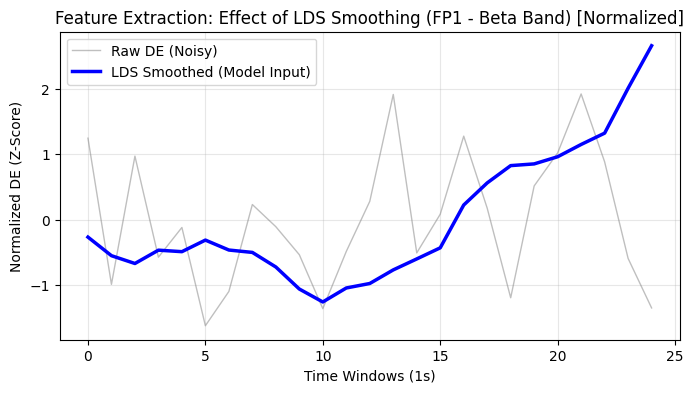

In [ ]:

# --- PLOT 2: Smoothing Effect (Normalized Comparison) ---
min_len = min(len(noisy_de_series), len(smooth_de_series))

# Normalize both to compare dynamics (ignores absolute scaling differences)
noisy_norm = z_score(noisy_de_series[:min_len])
smooth_norm = z_score(smooth_de_series[:min_len])

plt.figure(figsize=(8, 4))
plt.plot(noisy_norm, color='gray', alpha=0.5, linewidth=1, label='Raw DE (Noisy)')
plt.plot(smooth_norm, color='blue', linewidth=2.5, label='LDS Smoothed (Model Input)')
plt.title(f'Feature Extraction: Effect of LDS Smoothing ({channel_name} - {TARGET_BAND_NAME} Band) [Normalized]')
plt.xlabel('Time Windows (1s)')
plt.ylabel('Normalized DE (Z-Score)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import scipy.io
import scipy.io
import scipy.signal
import numpy as np
import matplotlib.pyplot as plt

mat = sio.loadmat("/content/eeg_raw_data/1/14_20151205.mat")
trial_keys = sorted([k for k in mat.keys() if "_eeg" in k and k.split("_eeg")[-1].isdigit()],
                    key=lambda x: int(x.split("_eeg")[-1]))

raw = mat[trial_keys[0]]   # (62, 33601) — first trial
ORIG_SFREQ   = 1000
TARGET_SFREQ = 200
BANDS = {"delta": (0.5,4), "theta": (4,8), "alpha": (8,13), "beta": (13,30), "gamma": (30,75)}
CH = 0  # change this to plot a different channel

# Downsample
eeg = raw[:, ::ORIG_SFREQ//TARGET_SFREQ]   # (62, ~6720)

# Bandpass filter
nyq = TARGET_SFREQ / 2
b, a = scipy.signal.butter(4, [0.5/nyq, 75/nyq], btype="band")
eeg = scipy.signal.filtfilt(b, a, eeg, axis=1)

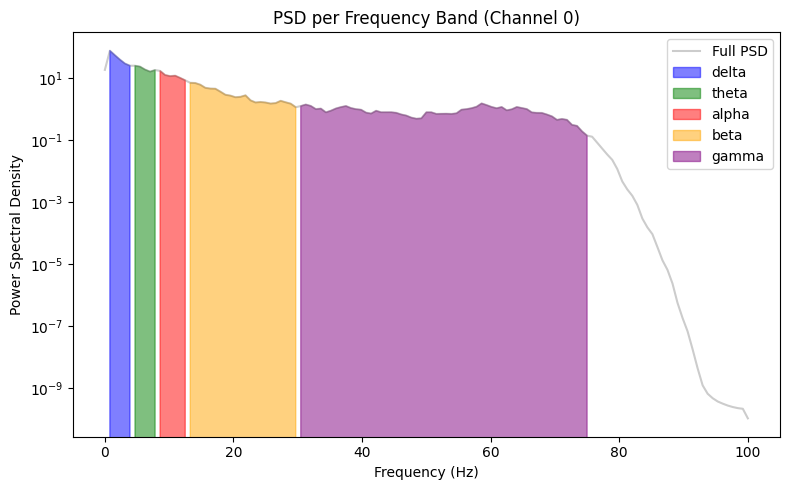

In [ ]:
freqs, psd = scipy.signal.welch(eeg[CH], fs=TARGET_SFREQ, nperseg=256)
band_colors = {"delta":"blue","theta":"green","alpha":"red","beta":"orange","gamma":"purple"}

plt.figure(figsize=(8, 5))
plt.semilogy(freqs, psd, color="gray", alpha=0.4, label="Full PSD")
for band, (low, high) in BANDS.items():
    idx = np.where((freqs >= low) & (freqs <= high))[0]
    plt.fill_between(freqs[idx], psd[idx], alpha=0.5, color=band_colors[band], label=band)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title(f"PSD per Frequency Band (Channel {CH})")
plt.legend()
plt.tight_layout()
plt.show()

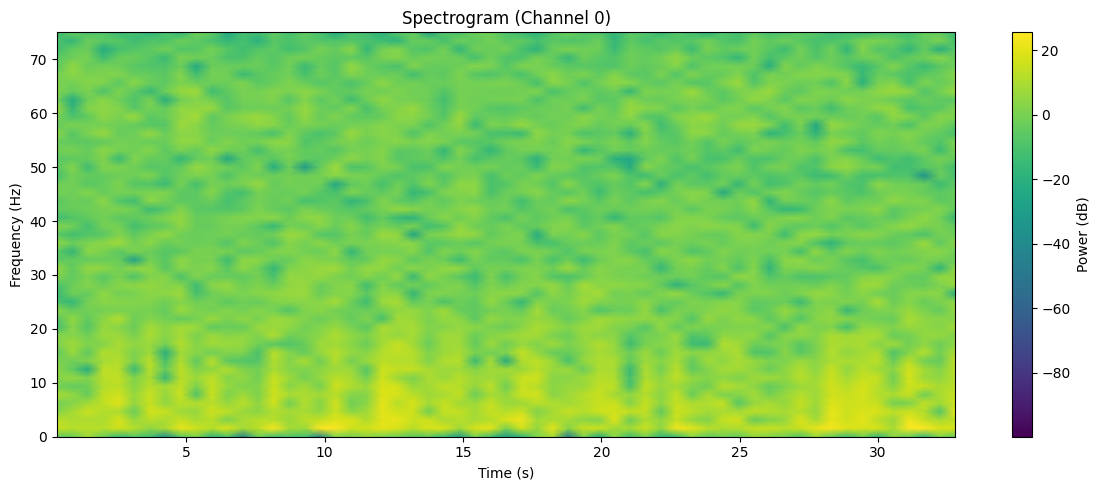

In [ ]:
f, t, Sxx = scipy.signal.spectrogram(eeg[CH], fs=TARGET_SFREQ, nperseg=128)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading="gouraud", cmap="viridis")
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 75)
plt.title(f"Spectrogram (Channel {CH})")
plt.tight_layout()
plt.show()

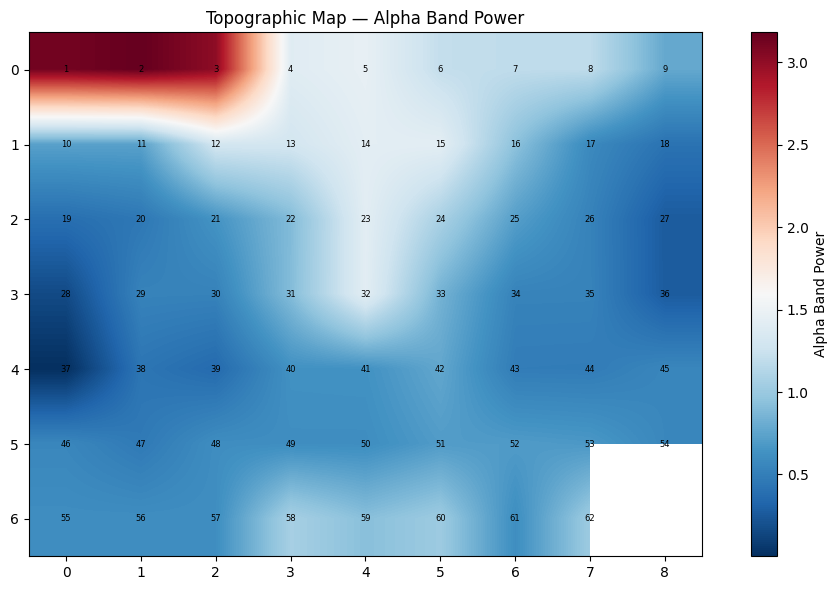

In [ ]:
freqs_all, psd_all = scipy.signal.welch(eeg, fs=TARGET_SFREQ, nperseg=256, axis=1)
low, high = BANDS["alpha"]
idx = np.where((freqs_all >= low) & (freqs_all <= high))[0]
band_power = psd_all[:, idx].mean(axis=1)  # (62,)

grid_rows, grid_cols = 7, 9
padded = np.full(grid_rows * grid_cols, np.nan)
padded[:62] = band_power
grid = padded.reshape(grid_rows, grid_cols)

plt.figure(figsize=(10, 6))
im = plt.imshow(grid, cmap="RdBu_r", interpolation="bilinear")
plt.colorbar(im, label="Alpha Band Power")
plt.title("Topographic Map — Alpha Band Power")
for i in range(62):
    r, c = divmod(i, grid_cols)
    plt.text(c, r, str(i+1), ha="center", va="center", fontsize=6)
plt.tight_layout()
plt.show()

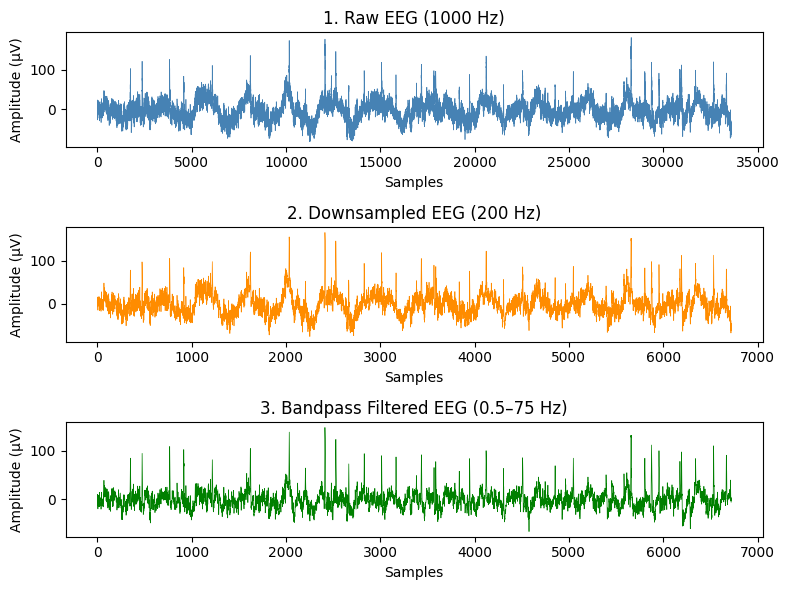

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=False)

# 1. Raw EEG
axes[0].plot(raw[CH], color="steelblue", linewidth=0.5)
axes[0].set_title("1. Raw EEG (1000 Hz)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Amplitude (µV)")

# 2. Downsampled
eeg_down = raw[:, ::ORIG_SFREQ//TARGET_SFREQ]
axes[1].plot(eeg_down[CH], color="darkorange", linewidth=0.5)
axes[1].set_title("2. Downsampled EEG (200 Hz)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Amplitude (µV)")

# 3. Filtered
nyq = TARGET_SFREQ / 2
b, a = scipy.signal.butter(4, [0.5/nyq, 75/nyq], btype="band")
eeg_filt = scipy.signal.filtfilt(b, a, eeg_down, axis=1)
axes[2].plot(eeg_filt[CH], color="green", linewidth=0.5)
axes[2].set_title("3. Bandpass Filtered EEG (0.5–75 Hz)")
axes[2].set_xlabel("Samples")
axes[2].set_ylabel("Amplitude (µV)")

plt.tight_layout()
plt.show()

In [ ]:

def load_seed_iv_lds(path):
    """Loads SEED-IV pre-computed LDS features."""
    feature_root = os.path.join(path, 'eeg_feature_smooth')
    if not os.path.exists(feature_root):
        feature_root = os.path.join(path, 'eeg_feature_smooth', 'eeg_feature_smooth')

    print(f"\nLoading data from: {feature_root}")

    data_lists = {'trial_data': [], 'label': [], 'subject': [], 'session': []}
    total_samples = 0

    for session_id in [1, 2, 3]:
        session_path = os.path.join(feature_root, str(session_id))
        if not os.path.exists(session_path): continue

        files = sorted([f for f in os.listdir(session_path) if f.endswith('.mat')])

        for fname in tqdm(files, desc=f"Processing Session {session_id}"):
            try:
                subject_id = int(fname.split('_')[0])
                mat = scipy.io.loadmat(os.path.join(session_path, fname))
            except Exception as e:
                continue

            for i, label in enumerate(SESSION_LABELS[session_id]):
                key = f'de_LDS{i+1}'
                if key not in mat: continue

                # Raw Shape: (62 Channels, Time, 5 Bands) -> Transpose to (Time, 62, 5)
                raw_trial = mat[key]
                trial_data = np.transpose(raw_trial, (1, 0, 2))


                n_windows = trial_data.shape[0]

                data_lists['trial_data'].append(trial_data)
                data_lists['label'].append(np.full(n_windows, label))
                data_lists['subject'].append(np.full(n_windows, subject_id))
                data_lists['session'].append(np.full(n_windows, session_id))

                total_samples += n_windows

    return (
        np.concatenate(data_lists['trial_data']),
        np.concatenate(data_lists['label']),
        np.concatenate(data_lists['subject']),
        np.concatenate(data_lists['session'])
    )

def apply_subject_zscore(data, subject_ids):
    """Applies Z-Score normalization per subject."""
    print("Applying Subject-Specific Z-Score Normalization...")
    normalized = np.zeros_like(data, dtype=np.float32)

    unique_subs = np.unique(subject_ids)
    for sub in tqdm(unique_subs, desc="Normalizing"):
        mask = (subject_ids == sub)
        sub_data = data[mask]

        mean = np.mean(sub_data, axis=0, keepdims=True)
        std = np.std(sub_data, axis=0, keepdims=True)
        std = np.where(std < 1e-8, 1.0, std)

        normalized[mask] = (sub_data - mean) / std

    return normalized

# --- Execution ---
trial_data_raw, labels, sub_ids, sess_ids = load_seed_iv_lds("/content/")
trial_data_norm = apply_subject_zscore(trial_data_raw, sub_ids)


Loading data from: /content/eeg_feature_smooth


Processing Session 1:   0%|          | 0/15 [00:00<?, ?it/s]

Processing Session 2:   0%|          | 0/15 [00:00<?, ?it/s]

Processing Session 3:   0%|          | 0/15 [00:00<?, ?it/s]

Applying Subject-Specific Z-Score Normalization...


Normalizing:   0%|          | 0/15 [00:00<?, ?it/s]

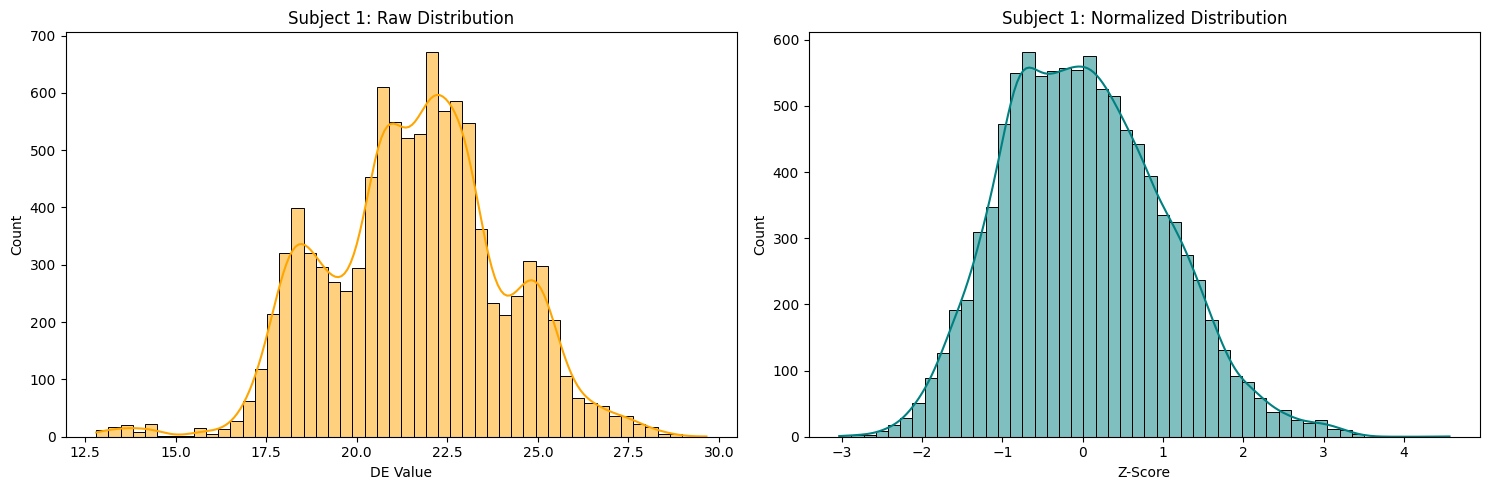

In [ ]:
def plot_normalization_effect(raw_data, norm_data, subject_id, sub_ids):
    mask = sub_ids == subject_id
    raw_sub = raw_data[mask].flatten()
    norm_sub = norm_data[mask].flatten()

    # Downsample
    if len(raw_sub) > 10000:
        idx = np.random.choice(len(raw_sub), 10000, replace=False)
        raw_sub = raw_sub[idx]
        norm_sub = norm_sub[idx]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(raw_sub, bins=50, kde=True, ax=axes[0], color='orange')
    axes[0].set_title(f"Subject {subject_id}: Raw Distribution")
    axes[0].set_xlabel("DE Value")

    sns.histplot(norm_sub, bins=50, kde=True, ax=axes[1], color='teal')
    axes[1].set_title(f"Subject {subject_id}: Normalized Distribution")
    axes[1].set_xlabel("Z-Score")

    plt.tight_layout()
    plt.show()

plot_normalization_effect(trial_data_raw, trial_data_norm, subject_id=1, sub_ids=sub_ids)


EXPLORATORY DATA ANALYSIS

[1] Class Distribution Table:


,Count,Percentage
Fear,9225,24.55
Happy,7935,21.12
Neutral,10170,27.07
Sad,10245,27.27



[2] Label-wise Frequency Band Distribution

Mean Differential Entropy (DE) by Band and Emotion:


Label,Fear,Happy,Neutral,Sad
Band,,,,
Alpha,-0.353124,0.167676,0.109349,0.079549
Beta,-0.225938,0.248104,-0.095560,0.106141
Delta,-0.023087,0.199041,-0.004918,-0.128492
Gamma,-0.090790,0.290574,-0.118851,-0.025324
Theta,-0.133477,0.308812,0.008248,-0.127181


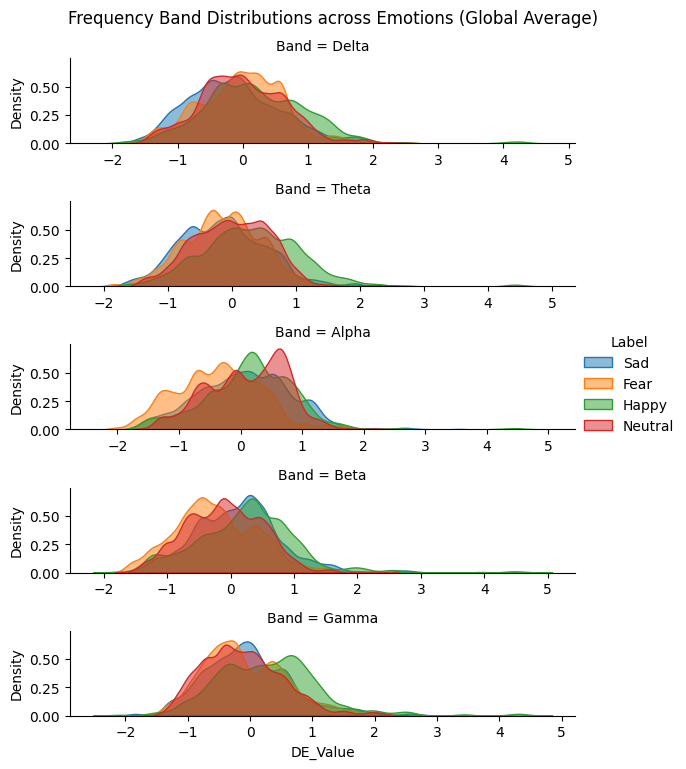

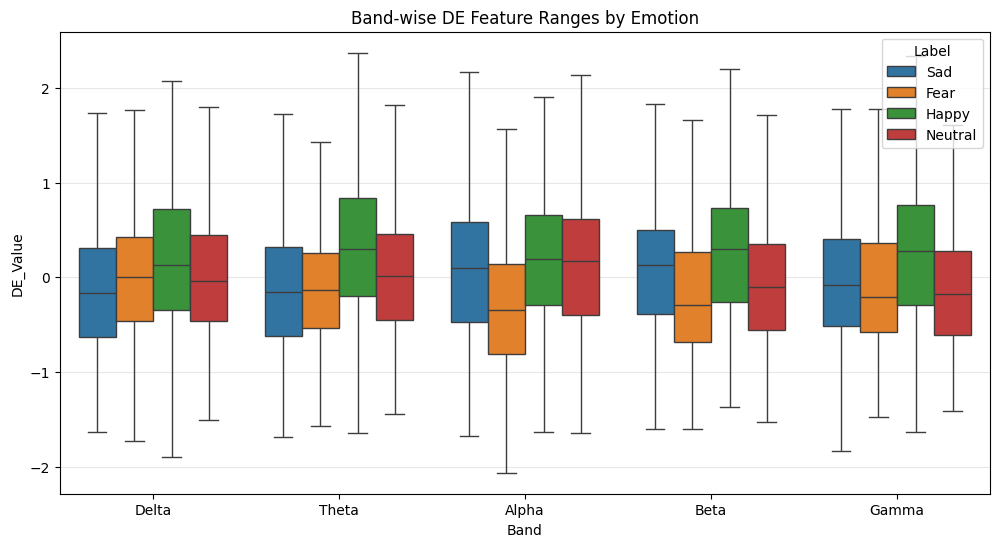

In [ ]:
import pandas as pd

def perform_eda(features, labels):
    print("\n" + "="*50)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*50)

    # --- 1. Class Distribution ---
    class_names = {0: 'Neutral', 1: 'Sad', 2: 'Fear', 3: 'Happy'}
    label_counts = pd.Series(labels).map(class_names).value_counts().sort_index()

    # Table
    dist_df = pd.DataFrame({
        'Count': label_counts.values,
        'Percentage': (label_counts.values / len(labels) * 100).round(2)
    }, index=label_counts.index)

    print("\n[1] Class Distribution Table:")
    display(dist_df)

    # # Plot
    # plt.figure(figsize=(8, 4))
    # sns.barplot(x=dist_df.index, y=dist_df['Count'], palette='viridis')
    # plt.title("Emotion Label Distribution")
    # plt.ylabel("Number of Samples")
    # plt.xlabel("Emotion Class")
    # plt.grid(axis='y', alpha=0.3)
    # plt.show()

    # --- 2. Band-wise Distribution ---
    print("\n[2] Label-wise Frequency Band Distribution")

    # Prepare Data: Average over channels to get global band power per sample
    # Shape: (N, 62, 5) -> (N, 5)
    band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
    features_avg = features.mean(axis=1)

    # Create DataFrame for Seaborn
    df_bands = pd.DataFrame(features_avg, columns=band_names)
    df_bands['Label'] = pd.Series(labels).map(class_names)

    # Melt for FacetGrid
    df_melt = df_bands.melt(id_vars='Label', var_name='Band', value_name='DE_Value')

    # Table: Mean DE per Band per Label
    pivot_table = df_melt.pivot_table(index='Band', columns='Label', values='DE_Value', aggfunc='mean')
    print("\nMean Differential Entropy (DE) by Band and Emotion:")
    display(pivot_table.style.background_gradient(cmap='coolwarm', axis=1))

    # Plot: Facet Grid (Rows=Bands)
    g = sns.FacetGrid(df_melt, row="Band", hue="Label", aspect=4, height=1.5, palette="tab10", sharex=False)
    g.map(sns.kdeplot, "DE_Value", fill=True, alpha=0.5)
    g.add_legend()
    g.fig.suptitle("Frequency Band Distributions across Emotions (Global Average)", y=1.02)
    plt.show()

    # Alternative Boxplot for clearer separation check
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_melt, x='Band', y='DE_Value', hue='Label', palette='tab10', showfliers=False)
    plt.title("Band-wise DE Feature Ranges by Emotion")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Run EDA on the normalized Teacher data
perform_eda(trial_data_norm, labels)